In [288]:
# imports and plotting defaults
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from long_term_wear_plotting import (
    mask_to_segments,
    merge_close_segments,
    drop_tiny_segments,
    plot_group,
    plot_all_signals_one_figure,
    keep_min_duration_segments,
    add_wrist_flex_ext_from_imus,
)

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = False

In [289]:
# fixed display settings
adc_ylim_map = {
    "ADC_ch0": (1.26, 1.36),  # Index
    "ADC_ch1": (1.30, 1.40),  # Thumb
    # "ADC_ch0": (1.2, 1.5),  # Index
    # "ADC_ch1": (1.2, 1.5),  # Thumb

}

label_colors = {
    "walking": "#5B8FF9", #blue
    "typing": "#61DDAA", #green
    "eating": "#F6BD16", #yellow-orange
    "texting": "#F08BB4", #pink
    "resting": "#9270CA", #purple
    "bluetooth down": "#7F7F7F", #gray
    "sensor disconnected": "#D62728", #red
    "IMU2 disconnected": "#D62728", #red
    "pressure": "#5B8FF9", #blue
    "bending": "#F6BD16", #yellow-orange

}

display_name_map = {
    "ADC_ch0": "Index MCP (raw ADC)",
    "ADC_ch1": "Thumb MP (raw ADC)",
    "IMU1_H": "Wrist IMU H",
    "IMU1_P": "Wrist IMU P",
    "IMU1_R": "Wrist IMU R",
    "IMU1_W": "Wrist IMU W",
    "IMU1_X": "Wrist IMU X",
    "IMU1_Y": "Wrist IMU Y",
    "IMU1_Z": "Wrist IMU Z",
    "IMU2_H": "HB IMU H",
    "IMU2_P": "HB IMU P",
    "IMU2_R": "HB IMU R",
    "IMU2_W": "HB IMU W",
    "IMU2_X": "HB IMU X",
    "IMU2_Y": "HB IMU Y",
    "IMU2_Z": "HB IMU Z",
}

group_title_map = {
    "IMU1 Euler": "Wrist IMU Euler",
    "IMU2 Euler": "HB IMU Euler",
    "IMU1 Quaternion": "Wrist IMU Quaternion",
    "IMU2 Quaternion": "HB IMU Quaternion",
    "ADC": "Strain Sensors",
}

In [290]:
# choose session
session_date = "2026_03_05"
file_pattern = "battery_kinwatch_unified_*.csv"
# "2026_03_05": 6hr, battery, pressure, disconnect
# "2026_03_06": 6hr2
#file_pattern = "*_kinwatch_unified_*.csv" 

In [291]:
#loading file

# make Code/analysis importable so we can use the shared config.py
analysis_dir = Path.cwd().resolve().parent
if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

from config import path_to_repository

repo_dir = Path(path_to_repository).resolve()
data_root = repo_dir / "CSV Data" / "long_term_wear_data"

data_dir = data_root / session_date
csv_files = sorted(data_dir.glob(file_pattern))
if not csv_files:
    raise FileNotFoundError(f"No files matching {file_pattern} found in {data_dir}")

csv_path = csv_files[-1]
print("Using file:", csv_path)

df = pd.read_csv(csv_path)

df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["Timestamp"]).sort_values("Timestamp").reset_index(drop=True)

t0 = df["Timestamp"].iloc[0]
df["elapsed_sec"] = (df["Timestamp"] - t0).dt.total_seconds()
df["elapsed_min"] = df["elapsed_sec"] / 60
df["elapsed_hr"]  = df["elapsed_sec"] / 3600

# derive wrist flexion/extension from the two IMUs
df = add_wrist_flex_ext_from_imus(
    df,
    quat_order="wxyz",
    fixed_axis="y",
    moving_axis="y",
    plane_normal_axis="z",
    out_col="wrist_flex_ext_deg",
    zero_baseline=True,
    baseline_window_sec=10.0,
    baseline_stat="median",
    abs_value=False,   # starting with signed trace
    sign=1.0,          # change to -1.0 if the direction is flipped
)

print("Start:", df["Timestamp"].iloc[0])
print("End:  ", df["Timestamp"].iloc[-1])
print(f"Duration: {df['elapsed_hr'].iloc[-1]:.2f} hr")
print("Shape:", df.shape)

Using file: /Users/hannas/Desktop/SNEL/kinematics/Strain-Sensor-/CSV Data/long_term_wear_data/2026_03_05/battery_kinwatch_unified_20260305_175417.csv
Start: 2026-03-06 01:54:17.648000+00:00
End:   2026-03-06 05:47:50.780000+00:00
Duration: 3.89 hr
Shape: (2023369, 42)


In [292]:
# inspect cols
list(df.columns)

['Timestamp',
 'Counter',
 'IMU1_H',
 'IMU1_P',
 'IMU1_R',
 'IMU1_W',
 'IMU1_X',
 'IMU1_Y',
 'IMU1_Z',
 'IMU1_sys',
 'IMU1_gyro',
 'IMU1_accel',
 'IMU1_mag',
 'IMU2_H',
 'IMU2_P',
 'IMU2_R',
 'IMU2_W',
 'IMU2_X',
 'IMU2_Y',
 'IMU2_Z',
 'IMU2_sys',
 'IMU2_gyro',
 'IMU2_accel',
 'IMU2_mag',
 'ADC_ch0',
 'ADC_ch1',
 'Note',
 'elapsed_sec',
 'elapsed_min',
 'elapsed_hr',
 'euler1_w',
 'euler1_x',
 'euler1_y',
 'euler1_z',
 'euler2_w',
 'euler2_x',
 'euler2_y',
 'euler2_z',
 'imu_bend_deg',
 'imu_pitch_deg',
 'imu_azimuth_deg',
 'wrist_flex_ext_deg']

In [293]:
# printing rows with notes
if "Note" not in df.columns:
    raise ValueError("No 'Note' column found in this file.")

note_mask = df["Note"].fillna("").astype(str).str.strip() != ""
note_rows = df.loc[note_mask, ["Timestamp", "elapsed_min", "elapsed_hr", "Counter", "Note"]].copy()

print(f"Found {len(note_rows)} rows with notes")
note_rows

Found 0 rows with notes


,Timestamp,elapsed_min,elapsed_hr,Counter,Note


In [294]:
for _, row in note_rows.iterrows():
    print(f"{row['elapsed_min']:8.3f} min | {row['Timestamp']} | {row['Note']}")

end_min = df["elapsed_min"].iloc[-1]
print("end of recording:", end_min)

end of recording: 233.5522


In [295]:
# pick cols to plot
plot_groups = {
    "IMU1 Euler": ["IMU1_H", "IMU1_P", "IMU1_R"],
    "IMU1 Quaternion": ["IMU1_W", "IMU1_X", "IMU1_Y", "IMU1_Z"],
    "IMU2 Euler": ["IMU2_H", "IMU2_P", "IMU2_R"],
    "IMU2 Quaternion": ["IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"],
    "ADC": ["ADC_ch0", "ADC_ch1"],
}

plot_groups = {
    k: [c for c in v if c in df.columns]
    for k, v in plot_groups.items()
    if any(c in df.columns for c in v)
}

plot_groups

{'IMU1 Euler': ['IMU1_H', 'IMU1_P', 'IMU1_R'],
 'IMU1 Quaternion': ['IMU1_W', 'IMU1_X', 'IMU1_Y', 'IMU1_Z'],
 'IMU2 Euler': ['IMU2_H', 'IMU2_P', 'IMU2_R'],
 'IMU2 Quaternion': ['IMU2_W', 'IMU2_X', 'IMU2_Y', 'IMU2_Z'],
 'ADC': ['ADC_ch0', 'ADC_ch1']}

In [296]:
# defining activity segments to shade
manual_segments = [
    # # 6hr
    # {"start_min": 1.645383	, "end_min": 2.731767, "label": "texting"},
    # {"start_min": 22.442983	, "end_min": 24.432400, "label": "walking"},
    # {"start_min": 24.432400	, "end_min": 37.556183, "label": "eating"},
    # {"start_min": 37.795633	, "end_min": 51.315817, "label": "walking"},
    # {"start_min": 59.827533	, "end_min": 119.827533, "label": "resting"}, # end not real
    # {"start_min": 250.294733, "end_min": 252.248967, "label": "texting"},
    # {"start_min": 266.162883, "end_min": 296.162883, "label": "walking"}, # end not real
    # {"start_min": 310	, "end_min": end_min, "label": "resting"},

    # # 6hr2
    # {"start_min": 0	, "end_min": 8.444867	, "label": "eating"},
    # {"start_min": 8.444867		, "end_min": 55.995667, "label": "typing"},
    # {"start_min": 55.995667	, "end_min": 60.758667, "label": "walking"},
    # {"start_min": 60.758667	, "end_min": 76.985817, "label": "resting"},
    # {"start_min": 76.985817	, "end_min": 119.780083, "label": "walking"}, 
    # {"start_min": 119.780083, "end_min": end_min, "label": "typing"},
    
    # pressure 
    # {"start_min": 0.502400		, "end_min": 1.235583, "label": "pressure"},
    # {"start_min": 1.235583	, "end_min": end_min, "label": "bending"},

]


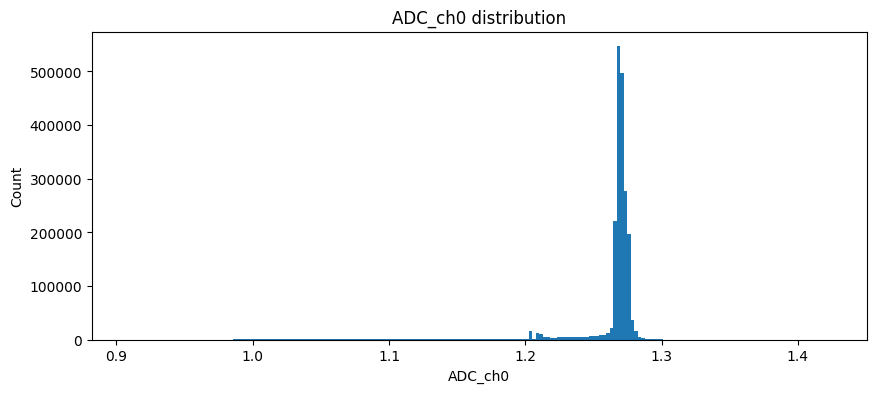

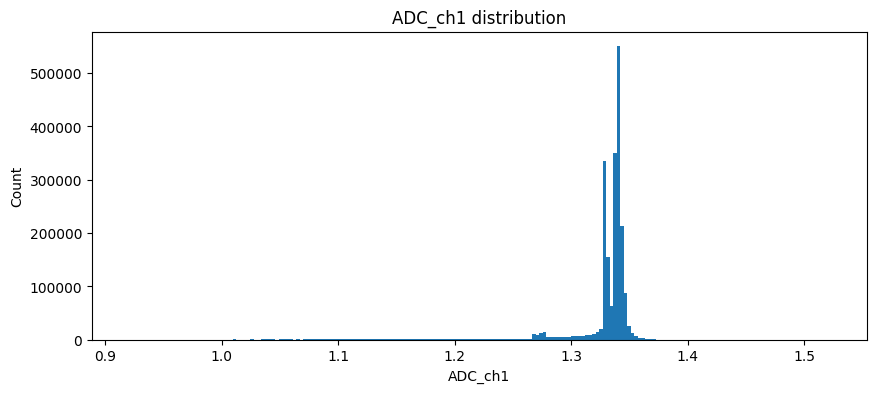

In [297]:
# inspecting ADC disttributions - help decide ylims & threshold
df[["ADC_ch0", "ADC_ch1"]].describe()

plt.figure(figsize=(10, 4))
plt.hist(df["ADC_ch0"].dropna(), bins=200)
plt.title("ADC_ch0 distribution")
plt.xlabel("ADC_ch0")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(df["ADC_ch1"].dropna(), bins=200)
plt.title("ADC_ch1 distribution")
plt.xlabel("ADC_ch1")
plt.ylabel("Count")
plt.show()

adc_disconnect_threshold = -1
gap_threshold_sec = 1

In [298]:
# detecting ADC disconnect
adc0_disconnected_mask = df["ADC_ch0"] < adc_disconnect_threshold
adc1_disconnected_mask = df["ADC_ch1"] < adc_disconnect_threshold

print("Rows flagged as ADC_ch0 disconnected:", int(adc0_disconnected_mask.sum()))
print("Rows flagged as ADC_ch1 disconnected:", int(adc1_disconnected_mask.sum()))

adc0_disconnect_segments = mask_to_segments(df, adc0_disconnected_mask, "sensor disconnected")
for seg in adc0_disconnect_segments:
    seg["channel"] = "ADC_ch0"

adc1_disconnect_segments = mask_to_segments(df, adc1_disconnected_mask, "sensor disconnected")
for seg in adc1_disconnect_segments:
    seg["channel"] = "ADC_ch1"

adc_disconnect_segments = adc0_disconnect_segments + adc1_disconnect_segments
pd.DataFrame(adc_disconnect_segments).head(20)

Rows flagged as ADC_ch0 disconnected: 0
Rows flagged as ADC_ch1 disconnected: 0


""


In [299]:
# detecting IMU2 disconnect 
imu2_zero_like = df.loc[
    (df["IMU2_W"].abs() < 1e-6) &
    (df["IMU2_X"].abs() < 1e-6) &
    (df["IMU2_Y"].abs() < 1e-6) &
    (df["IMU2_Z"].abs() < 1e-6),
    ["Timestamp", "elapsed_min", "IMU2_H", "IMU2_P", "IMU2_R", "IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"]
]

print(f"Rows with IMU2 quaternion all ~0: {len(imu2_zero_like)}")
imu2_zero_like.head(20)


imu2_disconnected_mask = (
    (df["IMU2_W"].abs() < 1e-6) &
    (df["IMU2_X"].abs() < 1e-6) &
    (df["IMU2_Y"].abs() < 1e-6) &
    (df["IMU2_Z"].abs() < 1e-6) &
    (df["IMU2_P"].abs() < 1e-6) &
    (df["IMU2_R"].abs() < 1e-6) &
    ((df["IMU2_H"] - 360).abs() < 1e-6)
)

print("Rows flagged as IMU2 disconnected:", int(imu2_disconnected_mask.sum()))
imu2_disconnect_segments = mask_to_segments(df, imu2_disconnected_mask, "IMU2 disconnected")

imu2_disconnect_segments_df = pd.DataFrame(imu2_disconnect_segments)
imu2_disconnect_segments_df.head(20)

Rows with IMU2 quaternion all ~0: 0
Rows flagged as IMU2 disconnected: 0


""


In [300]:
# detecting bluetooth-down
# dt_sec was around 0.002 -- so setting threshold to 0.5s for now
df["dt_sec"] = df["Timestamp"].diff().dt.total_seconds()
print(df["dt_sec"].describe())

gap_rows = df[df["dt_sec"] > gap_threshold_sec].copy()
print(f"Initially found {len(gap_rows)} possible Bluetooth gaps > {gap_threshold_sec} s")

bluetooth_segments = []

for idx in gap_rows.index:
    if idx == 0:
        continue

    prev_imu2_disc = bool(imu2_disconnected_mask.iloc[idx - 1]) if idx - 1 in imu2_disconnected_mask.index else False
    curr_imu2_disc = bool(imu2_disconnected_mask.iloc[idx]) if idx in imu2_disconnected_mask.index else False

    if prev_imu2_disc or curr_imu2_disc:
        continue

    bluetooth_segments.append({
        "start_min": float(df.loc[idx - 1, "elapsed_min"]),
        "end_min": float(df.loc[idx, "elapsed_min"]),
        "label": "bluetooth down",
        "gap_sec": float(df.loc[idx, "dt_sec"]),
        "start_time": df.loc[idx - 1, "Timestamp"],
        "end_time": df.loc[idx, "Timestamp"],
    })

bluetooth_segments_df = pd.DataFrame(bluetooth_segments)
print(f"Bluetooth gaps kept after excluding IMU2-disconnect boundaries: {len(bluetooth_segments)}")
bluetooth_segments_df

count    2.023368e+06
mean     6.925647e-03
std      1.797780e-02
min      0.000000e+00
25%      1.000000e-03
50%      2.000000e-03
75%      2.000000e-03
max      1.010000e-01
Name: dt_sec, dtype: float64
Initially found 0 possible Bluetooth gaps > 1 s
Bluetooth gaps kept after excluding IMU2-disconnect boundaries: 0


""


In [301]:
# using calibration from all 6 trials: 11/2, 11/4, 11/7 applications 1 + 2
# calibration was only done on Index MCP 

# load data
from analysis_adc_cam import ADC_CAM

CALIB_PARTICIPANTS = [
    {"name": "11_2", "root_dir": "CSV Data/11_2_25"},
    {"name": "11_4", "root_dir": "CSV Data/11_4_25"},
    {"name": "11_7", "root_dir": "CSV Data/11_7_25"},  # missing 90°
]

CALIB_KWARGS = dict(
    adc_column="adc_ch3",
    exclude_name_contains=("C_Block",),
    exclude_sets=(3, 4),
    snap_tol_deg=4.0,
    canonical_angles=(0, 22, 45, 67), # dropping 90 from all 
    make_plot=False,
)

ADC_BASELINE_SEC = 10.0
POOLED_ENDPOINT_DEG = 67.0

# incase polarity reversed 
INDEX_SIGN = -1.0
THUMB_SIGN = -1.0

# leave unclipped first; can set e.g. (-20, 40) or (0, 40) - biomechanics bound 
ANGLE_CLIP = None

In [302]:
# compute pooled calibration span in volts

calib_dfs = []
for p in CALIB_PARTICIPANTS:
    cam_p = ADC_CAM(
        root_dir=p["root_dir"],
        path_to_repo=path_to_repository,
        folder_suffix_first="B1_slow",
        folder_suffix_second="B2_slow",
    )
    df_p = cam_p.extract_calib_means_by_set(**CALIB_KWARGS)
    df_p["participant"] = p["name"]
    calib_dfs.append(df_p)

pooled_calib_df = pd.concat(calib_dfs, ignore_index=True)

# convert old raw adc counts -> volt-like units (reversing .js streaming)
cal = pooled_calib_df.copy()
cal["adc_mean_V"] = cal["adc_mean"].astype(float) / ((2**24) - 1) * 2.5

# per participant + app/ set, get the 0° and 67° references
ref0 = (
    cal[cal["angle_snap_deg"] == 0]
    .groupby(["participant", "set"])["adc_mean_V"]
    .median()
    .rename("adc0_ref_V")
    .reset_index()
)

ref67 = (
    cal[cal["angle_snap_deg"] == 67]
    .groupby(["participant", "set"])["adc_mean_V"]
    .median()
    .rename("adc67_ref_V")
    .reset_index()
)

cal = cal.merge(ref0, on=["participant", "set"], how="left")
cal = cal.merge(ref67, on=["participant", "set"], how="left")

cal["adc_span_0_to_67_V"] = cal["adc0_ref_V"] - cal["adc67_ref_V"]

span_by_trial = (
    cal.dropna(subset=["adc_span_0_to_67_V"])
    [["participant", "set", "adc0_ref_V", "adc67_ref_V", "adc_span_0_to_67_V"]]
    .drop_duplicates()
    .sort_values(["participant", "set"])
    .reset_index(drop=True)
)

pooled_span_0_to_67_V = span_by_trial["adc_span_0_to_67_V"].median()

display(span_by_trial)
print("Pooled median 0°→67° span (V):", pooled_span_0_to_67_V)

,participant,set,adc0_ref_V,adc67_ref_V,adc_span_0_to_67_V
0,11_2,1,1.357604,1.317073,0.040530
1,11_2,2,1.363038,1.331306,0.031732
2,11_4,1,1.364599,1.341107,0.023492
3,11_4,2,1.366637,1.336774,0.029863
4,11_7,1,1.359238,1.334895,0.024344
5,11_7,2,1.355906,1.317350,0.038556


Pooled median 0°→67° span (V): 0.03079759872875787


In [303]:
# convert the wear-session ADC channels to naive angle traces

df_final = df_plot.copy()

# use first few seconds as the session baseline for each channel
mask0 = df_final["elapsed_sec"] <= ADC_BASELINE_SEC

index_baseline_V = df_final.loc[mask0, "ADC_ch0"].median()
thumb_baseline_V = df_final.loc[mask0, "ADC_ch1"].median()

print("Index baseline V:", index_baseline_V)
print("Thumb baseline V:", thumb_baseline_V)
print("Using pooled span V:", pooled_span_0_to_67_V)

# positive bend if voltage drops below baseline (same direction as calibration)
df_final["index_mcp_deg"] = (INDEX_SIGN * POOLED_ENDPOINT_DEG * (index_baseline_V - df_final["ADC_ch0"]) / pooled_span_0_to_67_V)

df_final["thumb_mp_deg"] = (THUMB_SIGN * POOLED_ENDPOINT_DEG * (thumb_baseline_V - df_final["ADC_ch1"]) / pooled_span_0_to_67_V)

# preserve NaNs from disconnected source channels
df_final.loc[df_final["ADC_ch0"].isna(), "index_mcp_deg"] = np.nan
df_final.loc[df_final["ADC_ch1"].isna(), "thumb_mp_deg"] = np.nan

# optional clipping
if ANGLE_CLIP is not None:
    lo, hi = ANGLE_CLIP
    df_final["index_mcp_deg"] = df_final["index_mcp_deg"].clip(lo, hi)
    df_final["thumb_mp_deg"] = df_final["thumb_mp_deg"].clip(lo, hi)

print("\nIndex MCP angle summary:")
display(df_final["index_mcp_deg"].describe())

print("\nThumb MP angle summary:")
display(df_final["thumb_mp_deg"].describe())

print("\nQuantiles:")
display(
    pd.DataFrame({
        "index_mcp_deg": df_final["index_mcp_deg"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]),
        "thumb_mp_deg": df_final["thumb_mp_deg"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]),
    })
)

Index baseline V: 1.2721624970436096
Thumb baseline V: 1.3429638743400574
Using pooled span V: 0.03079759872875787

Index MCP angle summary:


count    2.023368e+06
mean    -1.714319e+01
std      5.940229e+01
min     -7.926279e+02
25%     -1.050907e+01
50%     -4.936520e+00
75%      6.794685e-01
max      3.321577e+02
Name: index_mcp_deg, dtype: float64


Thumb MP angle summary:


count    2.023367e+06
mean    -2.596129e+01
std      6.242467e+01
min     -9.229880e+02
25%     -2.831076e+01
50%     -9.885359e+00
75%     -3.693638e+00
max      3.931905e+02
Name: thumb_mp_deg, dtype: float64


Quantiles:


,index_mcp_deg,thumb_mp_deg
0.01,-334.979904,-339.734258
0.05,-118.304675,-131.541798
0.25,-10.509070,-28.310756
0.50,-4.936520,-9.885359
0.75,0.679469,-3.693638
0.95,9.605921,7.142848
0.99,20.228452,21.387698


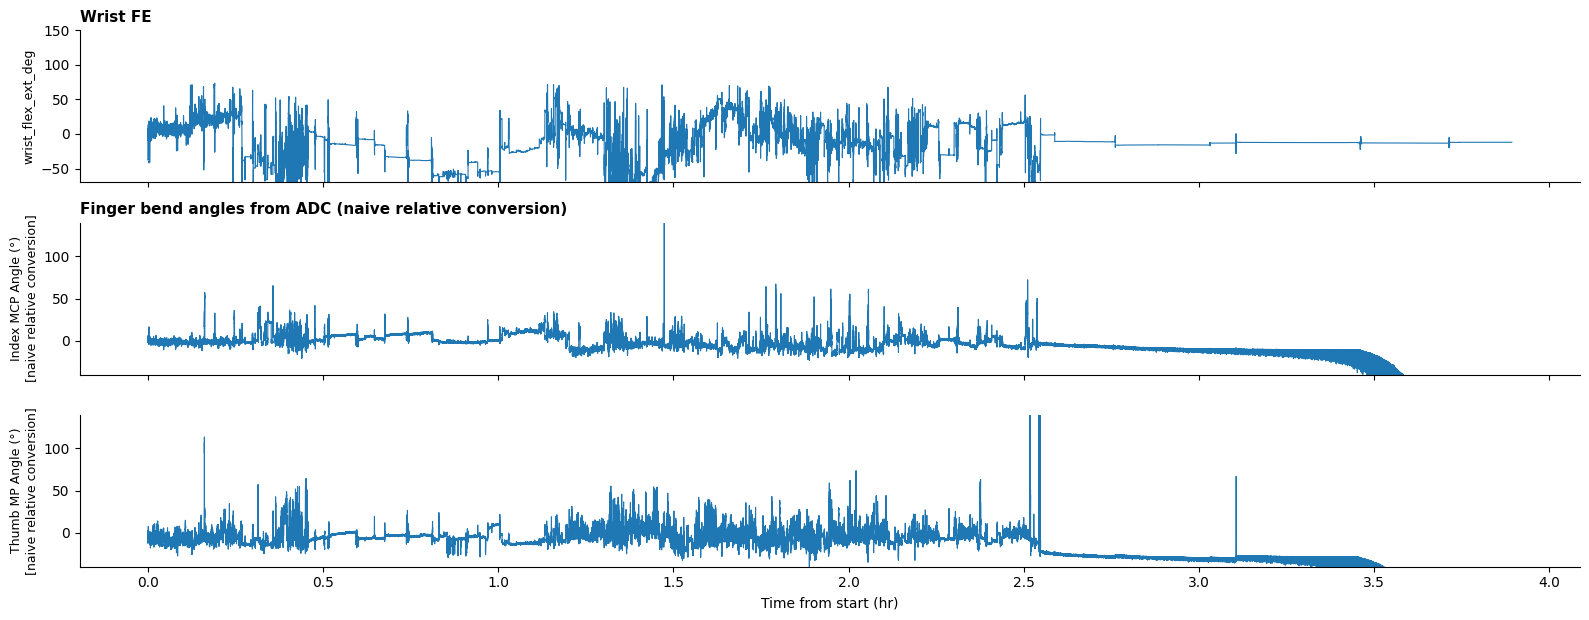

In [304]:
# labels + angle-only plot

display_name_map["index_mcp_deg"] = "Index MCP Angle (°)\n[naive relative conversion]"
display_name_map["thumb_mp_deg"] = "Thumb MP Angle (°)\n[naive relative conversion]"
group_title_map["Finger angles"] = "Finger bend angles from ADC (naive relative conversion)"

plot_groups_final = {
    "Wrist FE": ["wrist_flex_ext_deg"],
    "Finger angles": ["index_mcp_deg", "thumb_mp_deg"],
}

plot_groups_final = {
    k: [c for c in v if c in df_final.columns]
    for k, v in plot_groups_final.items()
    if any(c in df_final.columns for c in v)
}

adc_ylim_map_final = {
    "wrist_flex_ext_deg": (-70, 150),
    "index_mcp_deg": (-40, 140),
    "thumb_mp_deg": (-40, 140),
}


plot_all_signals_one_figure(
    df_final,
    plot_groups_final,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    adc_ylim_map=adc_ylim_map_final,
    xcol="elapsed_hr",
)

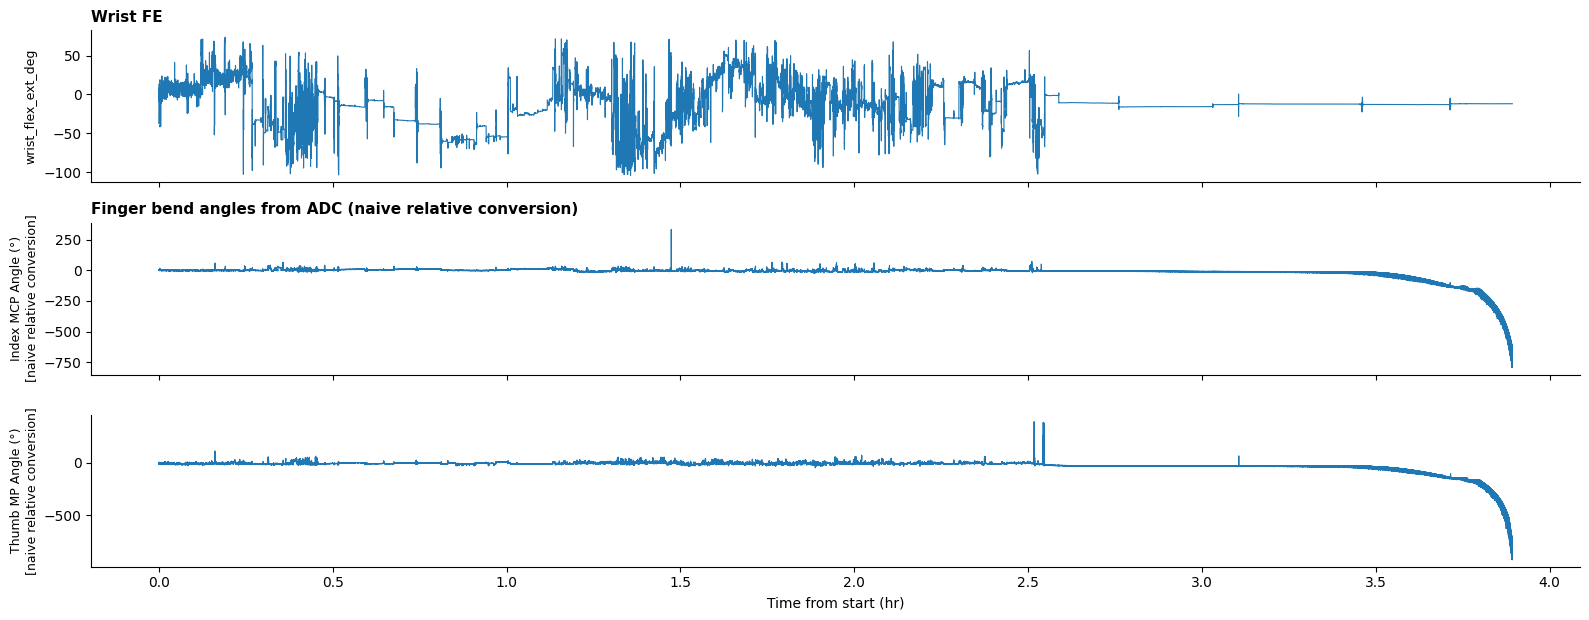

In [305]:
# final plot

# FINAL_WRIST_YLIM = (-60, 60)   # adjust if needed
# FINAL_FINGER_YLIM = (-20, 40)  # adjust if needed

plot_groups_final = {
    "Wrist FE": ["wrist_flex_ext_deg"],
    "Finger angles": ["index_mcp_deg", "thumb_mp_deg"],
}

plot_groups_final = {
    k: [c for c in v if c in df_final.columns]
    for k, v in plot_groups_final.items()
    if any(c in df_final.columns for c in v)
}

# adc_ylim_map_final = {
#     **adc_ylim_map,
#     # "wrist_flex_ext_deg": FINAL_WRIST_YLIM,
#     # "index_mcp_deg": FINAL_FINGER_YLIM,
#     # "thumb_mp_deg": FINAL_FINGER_YLIM,
# }

plot_all_signals_one_figure(
    df_final,
    plot_groups_final,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    #adc_ylim_map=adc_ylim_map_final,
    xcol="elapsed_hr",
)

In [306]:
# clean up auto-detected segments
adc0_disconnect_segments = merge_close_segments(adc0_disconnect_segments, max_gap_min=0.005)
adc1_disconnect_segments = merge_close_segments(adc1_disconnect_segments, max_gap_min=0.005)
imu2_disconnect_segments = merge_close_segments(imu2_disconnect_segments, max_gap_min=0.005)
bluetooth_segments = merge_close_segments(bluetooth_segments, max_gap_min=0.01)

adc0_disconnect_segments = drop_tiny_segments(adc0_disconnect_segments, min_duration_min=0.002)
adc1_disconnect_segments = drop_tiny_segments(adc1_disconnect_segments, min_duration_min=0.002)
imu2_disconnect_segments = drop_tiny_segments(imu2_disconnect_segments, min_duration_min=0.002)
bluetooth_segments = drop_tiny_segments(bluetooth_segments, min_duration_min=0.002)

imu2_disconnect_segments = merge_close_segments(imu2_disconnect_segments, max_gap_min=0.05)
imu2_disconnect_segments = keep_min_duration_segments(imu2_disconnect_segments, min_duration_min=0.25)

adc_disconnect_segments = adc0_disconnect_segments + adc1_disconnect_segments

print("ADC_ch0 cleaned segments:", len(adc0_disconnect_segments))
print("ADC_ch1 cleaned segments:", len(adc1_disconnect_segments))
print("IMU2 cleaned segments:", len(imu2_disconnect_segments))
print("Bluetooth cleaned segments:", len(bluetooth_segments))
print("Combined ADC cleaned segments:", len(adc_disconnect_segments))

ADC_ch0 cleaned segments: 0
ADC_ch1 cleaned segments: 0
IMU2 cleaned segments: 0
Bluetooth cleaned segments: 0
Combined ADC cleaned segments: 0


In [307]:
# replace with NaNs
df_plot = df.copy()

if "ADC_ch0" in df_plot.columns:
    df_plot.loc[adc0_disconnected_mask, "ADC_ch0"] = np.nan

if "ADC_ch1" in df_plot.columns:
    df_plot.loc[adc1_disconnected_mask, "ADC_ch1"] = np.nan

if "wrist_flex_ext_deg" in df_plot.columns:
    df_plot.loc[imu2_disconnected_mask, "wrist_flex_ext_deg"] = np.nan

imu2_cols = ["IMU2_H", "IMU2_P", "IMU2_R", "IMU2_W", "IMU2_X", "IMU2_Y", "IMU2_Z"]
for col in imu2_cols:
    if col in df_plot.columns:
        df_plot.loc[imu2_disconnected_mask, col] = np.nan

In [308]:
# chronological segment table
all_segments_chron = []

for seg in manual_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "manual"
    })

for seg in bluetooth_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "auto"
    })

for seg in adc_disconnect_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": seg.get("channel", "auto")
    })

for seg in imu2_disconnect_segments:
    all_segments_chron.append({
        "start_min": seg["start_min"],
        "end_min": seg["end_min"],
        "label": seg["label"],
        "source": "auto"
    })

if all_segments_chron:
    all_segments_chron_df = (
        pd.DataFrame(all_segments_chron)
        .sort_values(["start_min", "end_min"])
        .reset_index(drop=True)
    )
else:
    all_segments_chron_df = pd.DataFrame(columns=["start_min", "end_min", "label", "source"])

all_segments_chron_df

,start_min,end_min,label,source


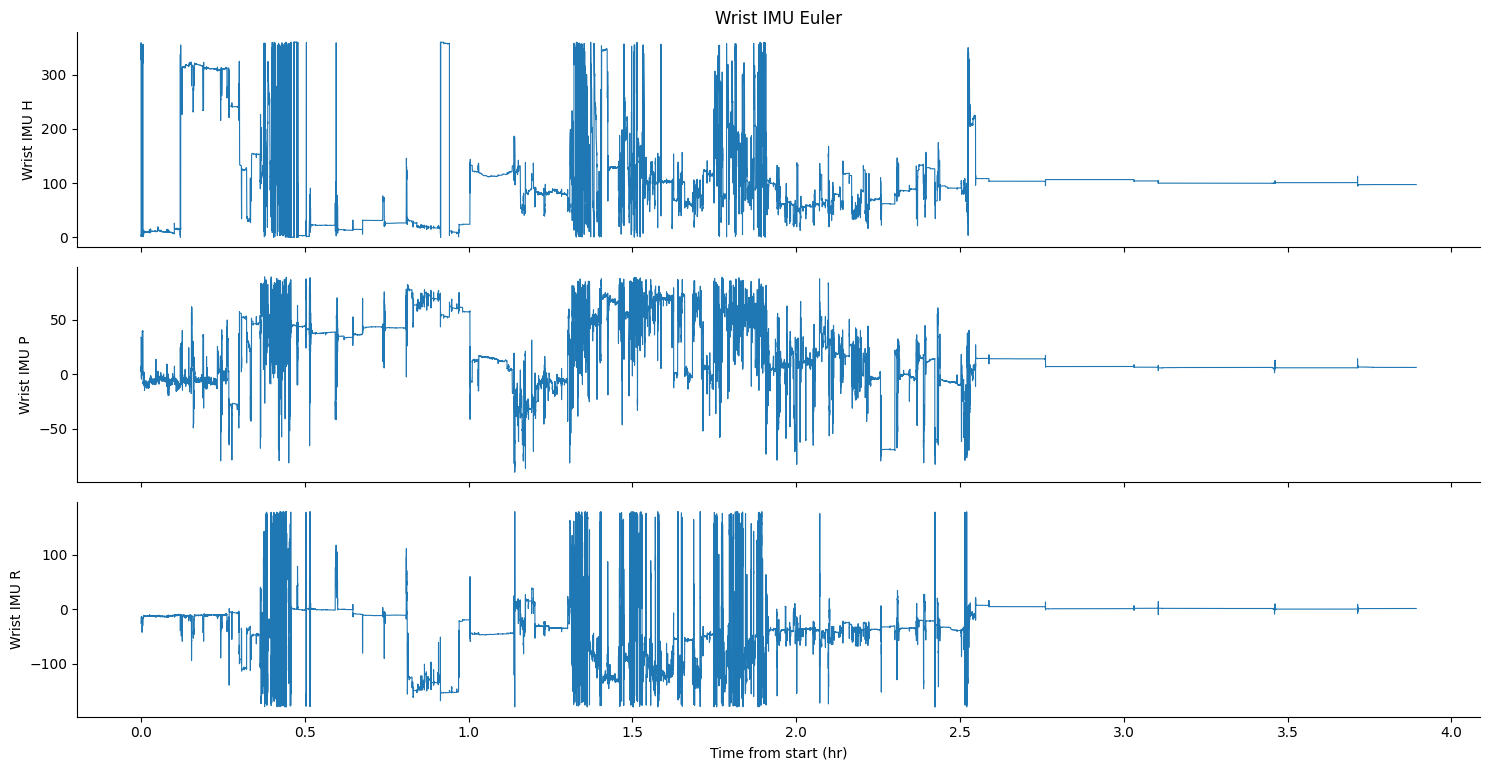

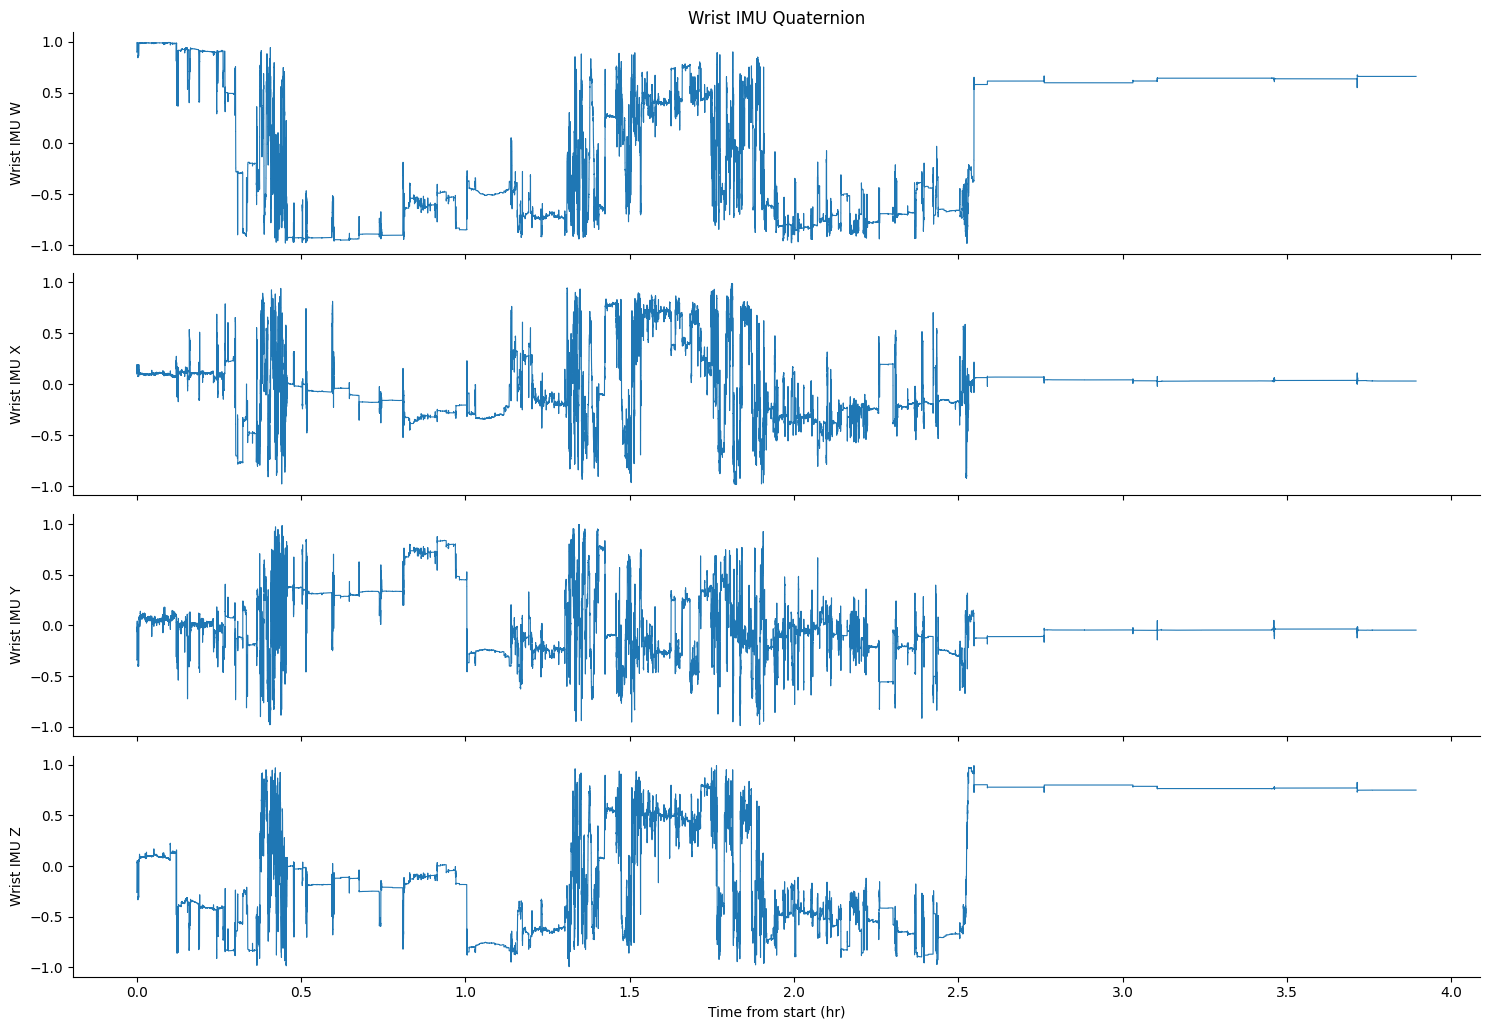

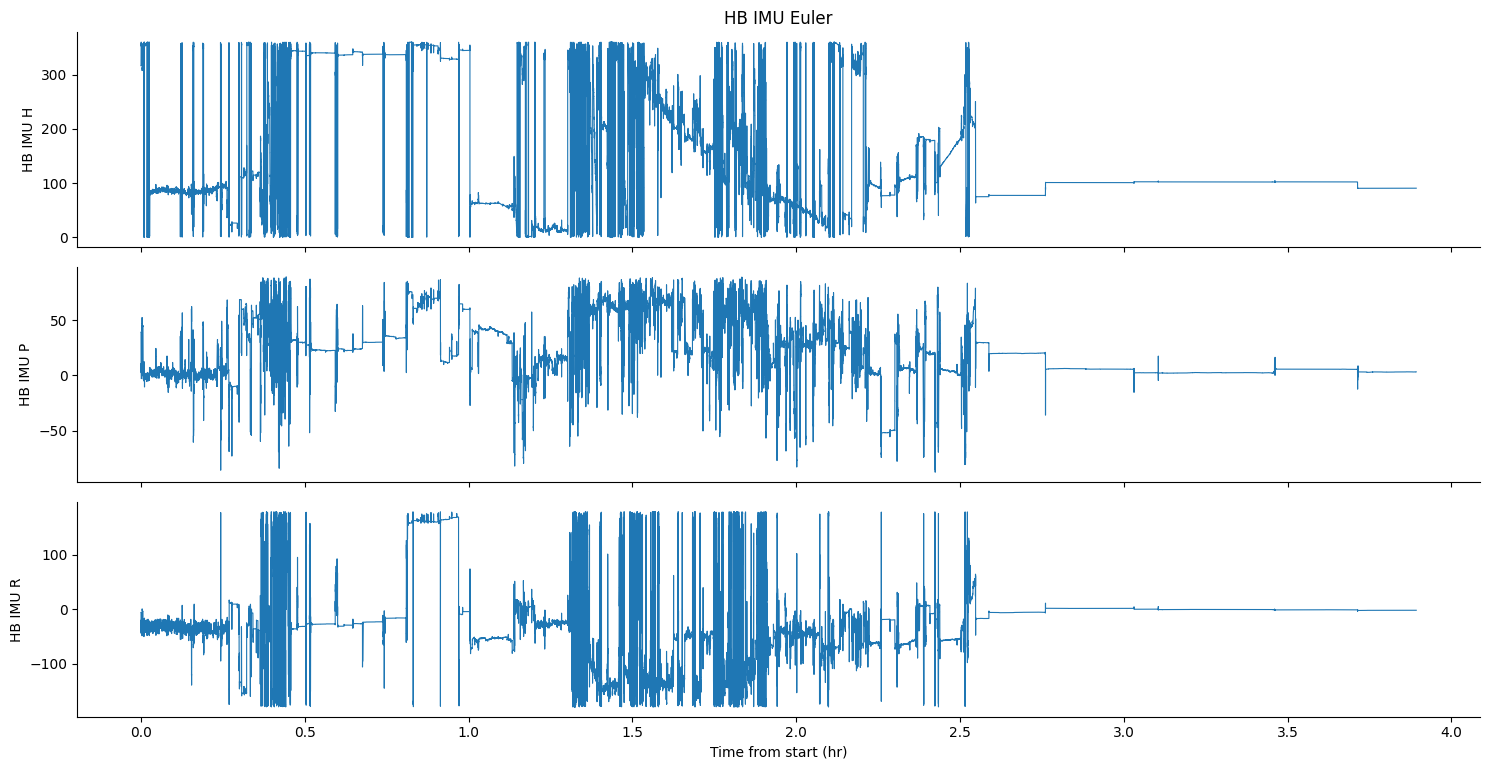

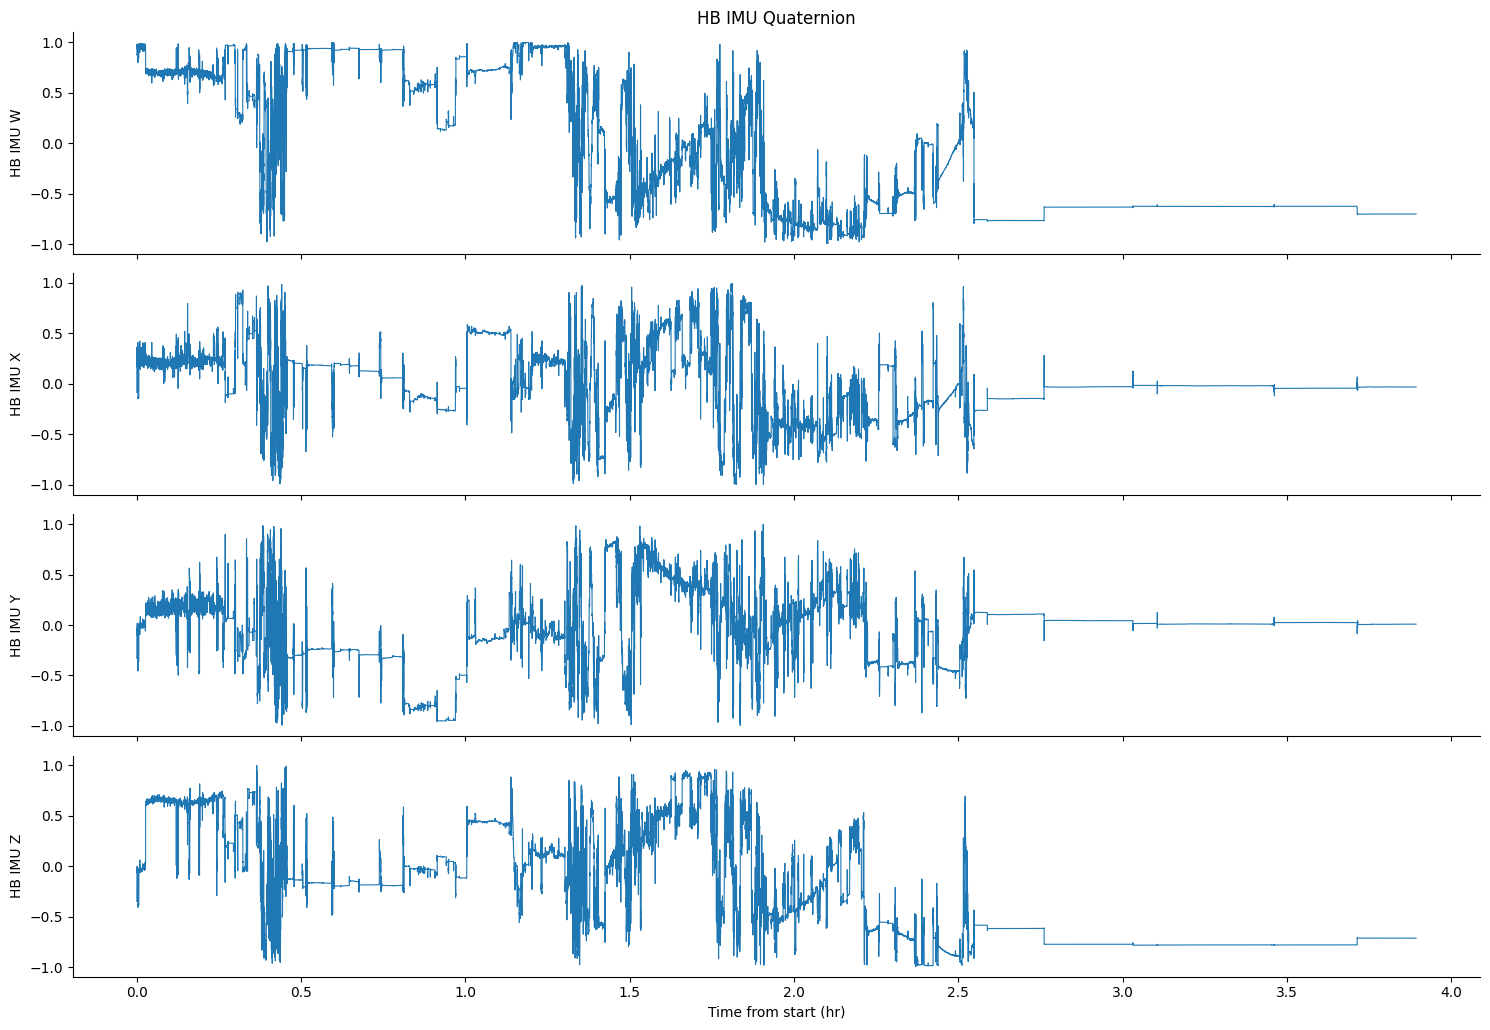

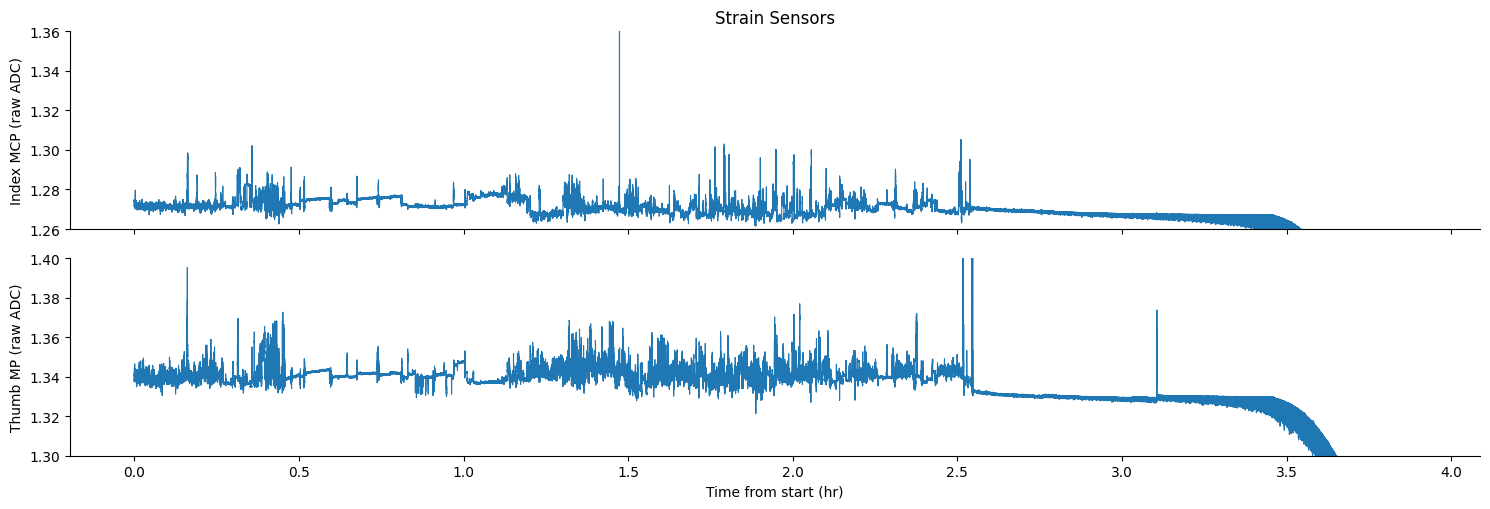

In [309]:
# individual plots
for title, cols in plot_groups.items():
    plot_group(
        df_plot,
        cols,
        title=title,
        manual_segments=manual_segments,
        bluetooth_segments=bluetooth_segments,
        adc_disconnect_segments=adc_disconnect_segments,
        imu2_disconnect_segments=imu2_disconnect_segments,
        label_colors=label_colors,
        display_name_map=display_name_map,
        group_title_map=group_title_map,
        adc_ylim_map=adc_ylim_map,
        xcol="elapsed_hr",
    )

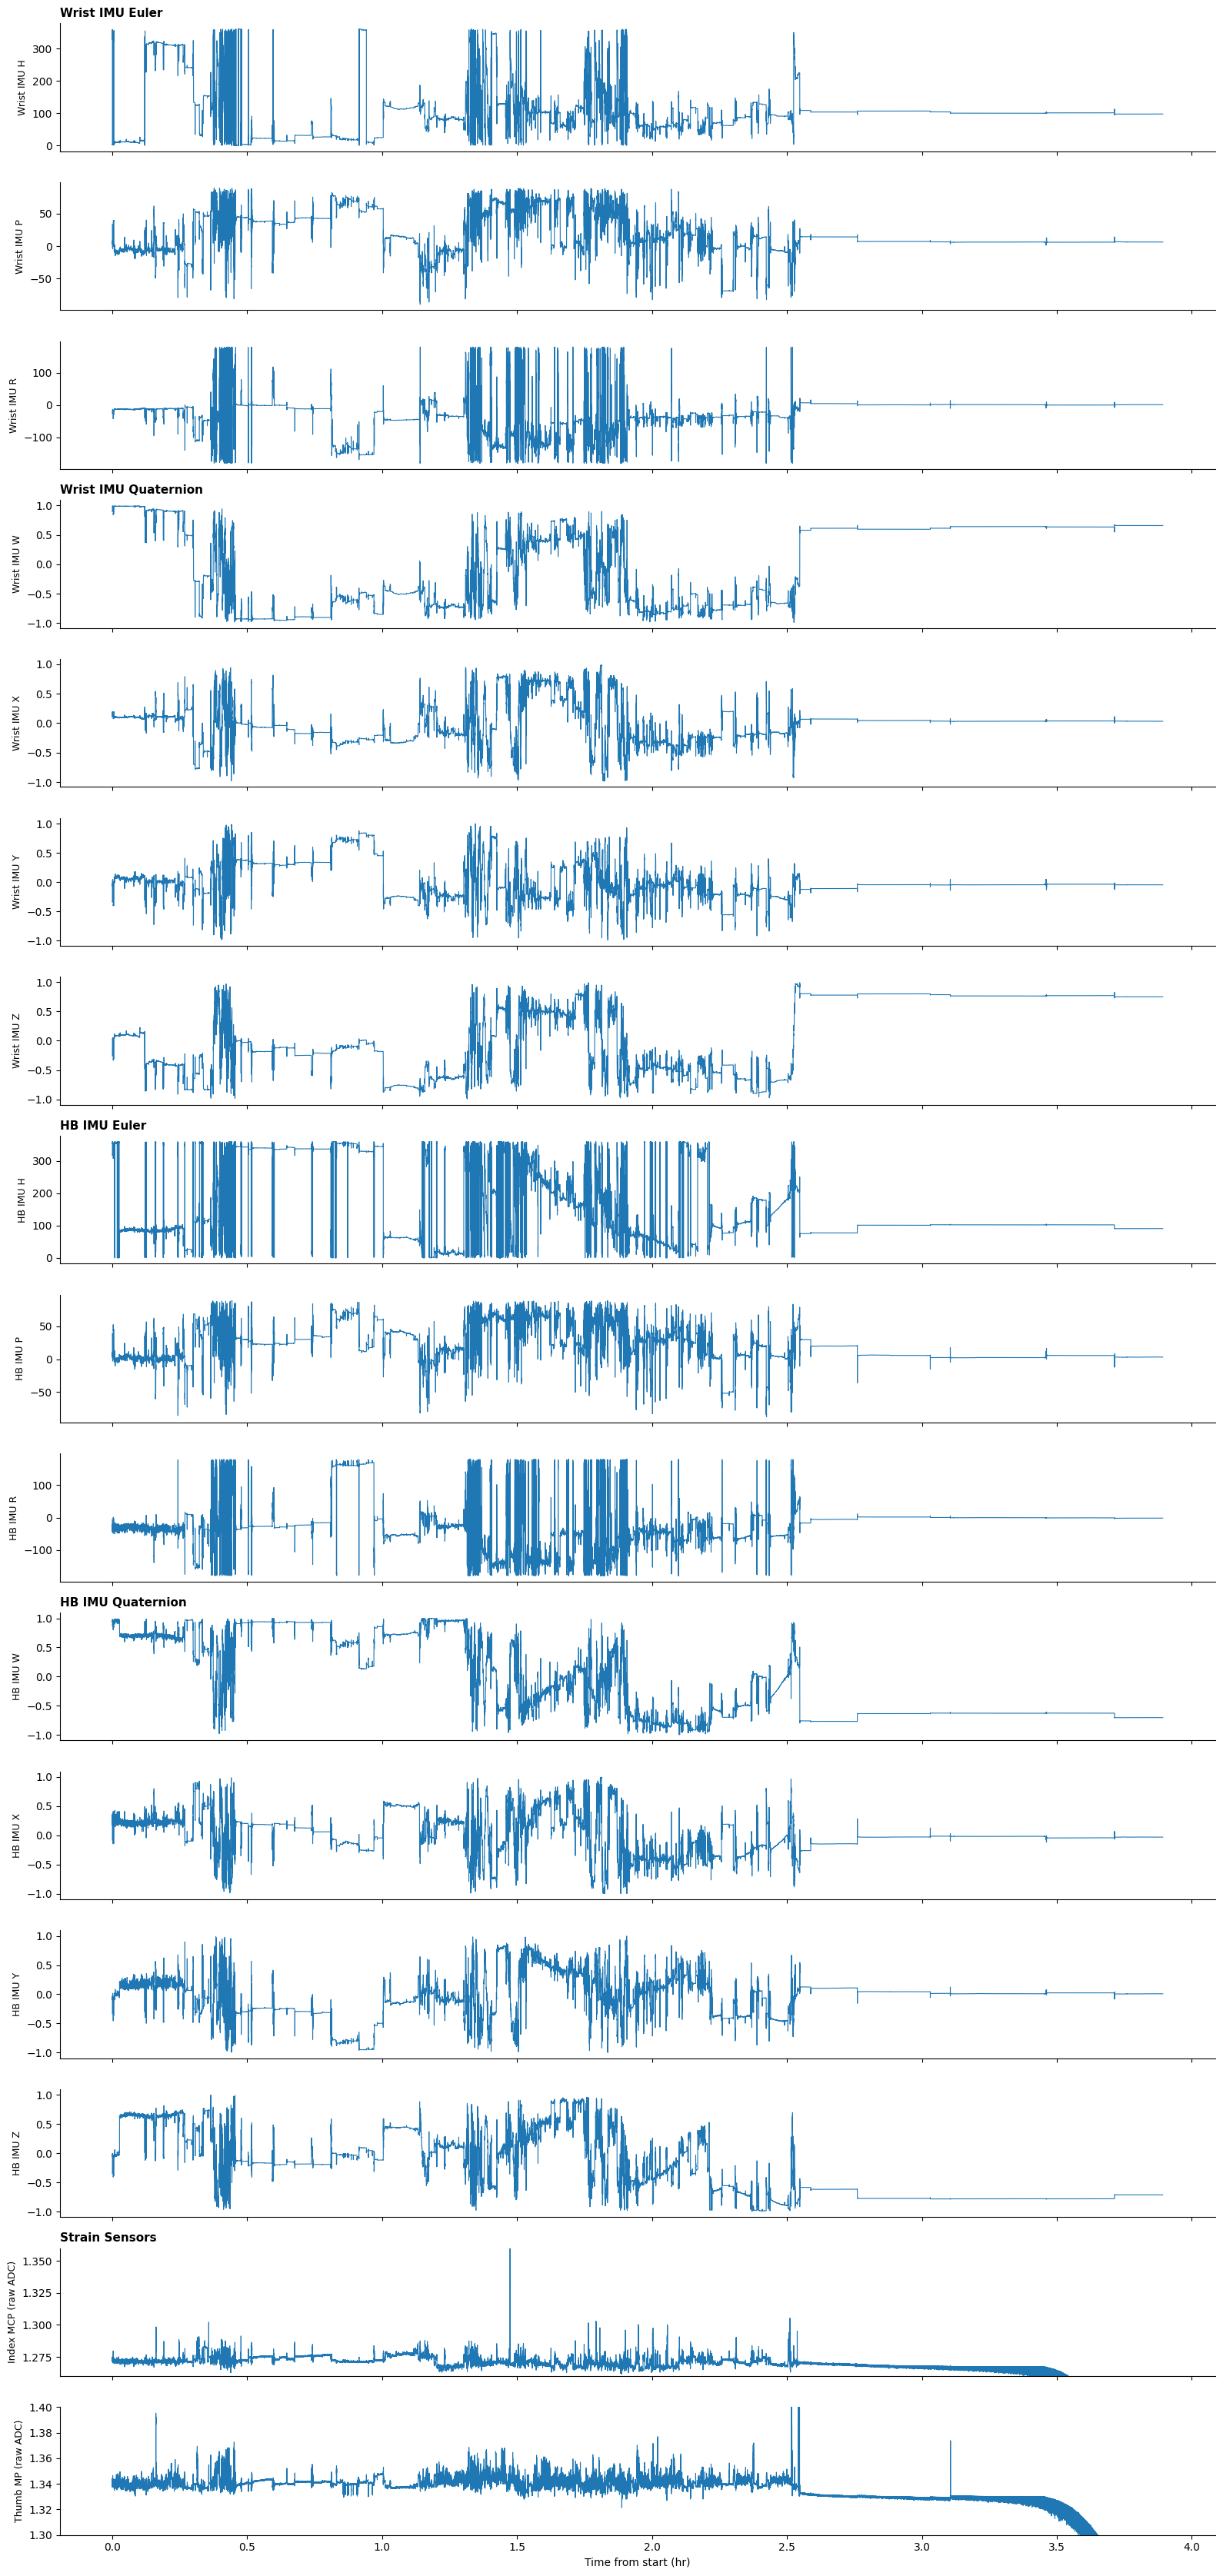

In [310]:
# combo plot
plot_all_signals_one_figure(
    df_plot,
    plot_groups,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    adc_ylim_map=adc_ylim_map,
    xcol="elapsed_hr",
)

## wrist flex/ext from IMU quats

In [311]:
# wrist flex/ext from IMU quats

# compute all Q_rel - bend, pitch, azimuth (default from structured on-hand)
from long_term_wear_plotting import add_wrist_flex_ext_from_imus

df_plot = add_wrist_flex_ext_from_imus(
    df_plot,
    fe_source_col="imu_azimuth_deg",  # placeholderrrrr: UPDATE in config cell -- been updated 
    out_col="wrist_flex_ext_deg",
    zero_baseline=False,              # keep raw for inspection
    sign=1.0,
)

# Add display names for the three intermediate cols
display_name_map["imu_bend_deg"]    = "IMU bend (°)"
display_name_map["imu_pitch_deg"]   = "IMU pitch (°)"
display_name_map["imu_azimuth_deg"] = "IMU azimuth (°)"
display_name_map["wrist_flex_ext_deg"] = "Wrist Flex/Ext (°)"
group_title_map["IMU angles"] = "IMU relative angles (bend / pitch / azimuth)"
group_title_map["Wrist FE"]   = "Wrist flexion / extension"

print("Intermediate columns added:", [c for c in df_plot.columns
      if c in ('imu_bend_deg','imu_pitch_deg','imu_azimuth_deg','wrist_flex_ext_deg')])
df_plot[['imu_bend_deg','imu_pitch_deg','imu_azimuth_deg']].describe()

Intermediate columns added: ['imu_bend_deg', 'imu_pitch_deg', 'imu_azimuth_deg', 'wrist_flex_ext_deg']


,imu_bend_deg,imu_pitch_deg,imu_azimuth_deg
count,2.023369e+06,2.023369e+06,2.023369e+06
mean,4.231947e+01,3.944468e+01,1.781288e+00
std,3.965070e+01,4.387947e+01,2.399245e+01
min,8.636381e-02,6.742953e-04,-8.973273e+01
25%,5.546848e+00,5.336386e+00,-6.948105e+00
50%,3.278978e+01,2.627125e+01,2.177439e+00
75%,5.958899e+01,5.316871e+01,1.326798e+01
max,1.785795e+02,1.799711e+02,8.819219e+01


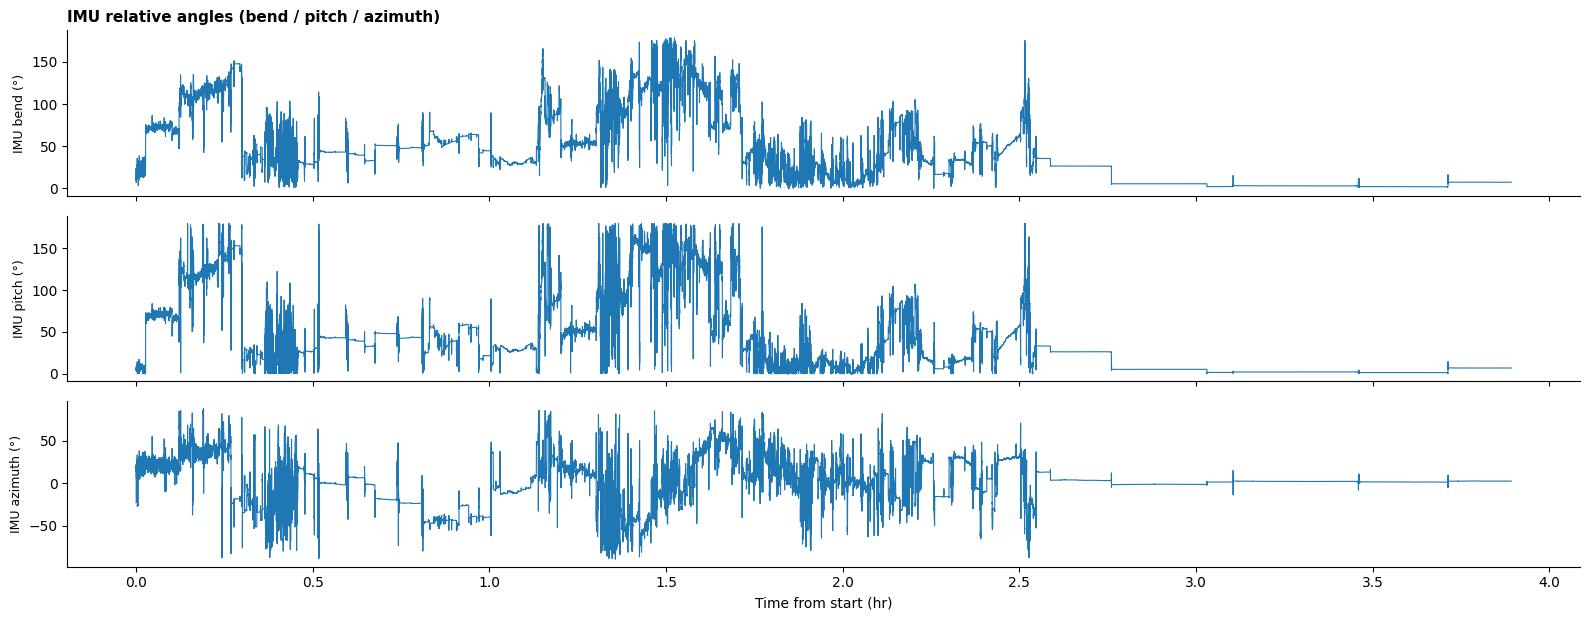

In [312]:
# review all 3 Q_rel
# lots of variation = typing
# no variation = resting
# review polarity too
plot_groups_angles = {
    "IMU angles": ["imu_bend_deg", "imu_pitch_deg", "imu_azimuth_deg"],
}

plot_all_signals_one_figure(
    df_plot,
    plot_groups_angles,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    xcol="elapsed_hr",
)

FE source: imu_azimuth_deg, sign=1.0, zero_baseline=True (median over 1.0s)
count    2.023369e+06
mean    -1.371176e+01
std      2.399245e+01
min     -1.052258e+02
25%     -2.244115e+01
50%     -1.331561e+01
75%     -2.225070e+00
max      7.269914e+01
Name: wrist_flex_ext_deg, dtype: float64


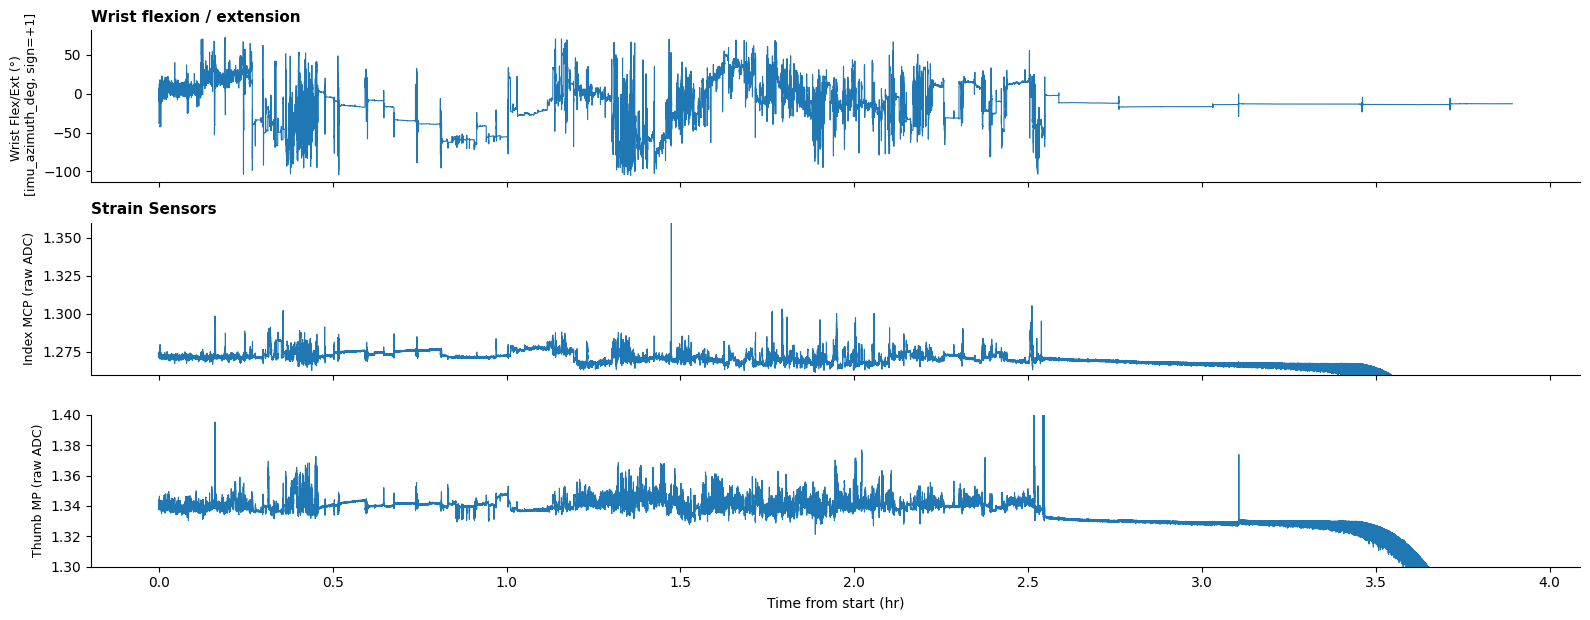

In [313]:
# set FE_SOURCE_COL
FE_SOURCE_COL      = "imu_azimuth_deg"  # "imu_bend_deg" #  "imu_pitch_deg"  
SIGN               = 1.0               # -1.0 to flip so extension > 0, flexion < 0
ZERO_BASELINE      = True
BASELINE_WINDOW_SEC = 1.0              # seconds of leading data used for baseline mean
BASELINE_STAT      = "median"          # "median" or "mean"
#FE_YLIM            = (-60, 60)         # y-axis limits for final plot; adjust to data
# ────────────────────────────────────────────────────────────────────────
print(f"FE source: {FE_SOURCE_COL}, sign={SIGN}, "
      f"zero_baseline={ZERO_BASELINE} ({BASELINE_STAT} over {BASELINE_WINDOW_SEC}s)")

df_plot = add_wrist_flex_ext_from_imus(
    df_plot,
    fe_source_col=FE_SOURCE_COL,
    out_col="wrist_flex_ext_deg",
    sign=SIGN,
    zero_baseline=ZERO_BASELINE,
    baseline_window_sec=BASELINE_WINDOW_SEC,
    baseline_stat=BASELINE_STAT,
    #plane_normal_axis='y' # or 'y' if default looks wrong 
)

display_name_map["wrist_flex_ext_deg"] = (
    f"Wrist Flex/Ext (°) \n [{FE_SOURCE_COL}, sign={SIGN:+.0f}]"
)

print(df_plot["wrist_flex_ext_deg"].describe())

# get real wrist_flex_ext_deg + final plot
plot_groups_fe = {
    "Wrist FE": ["wrist_flex_ext_deg"],
    "ADC":      ["ADC_ch0", "ADC_ch1"],
}
plot_groups_fe = {
    k: [c for c in v if c in df_plot.columns]
    for k, v in plot_groups_fe.items()
    if any(c in df_plot.columns for c in v)
}

adc_ylim_map_fe = {
    **adc_ylim_map,
    #"wrist_flex_ext_deg": FE_YLIM,
}

plot_all_signals_one_figure(
    df_plot,
    plot_groups_fe,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    adc_ylim_map=adc_ylim_map_fe,
    xcol="elapsed_hr",
)

## super naive ADC -> bend angle 

In [314]:
# using calibration from all 6 trials: 11/2, 11/4, 11/7 applications 1 + 2
# calibration was only done on Index MCP 

# load data
from analysis_adc_cam import ADC_CAM

CALIB_PARTICIPANTS = [
    {"name": "11_2", "root_dir": "CSV Data/11_2_25"},
    {"name": "11_4", "root_dir": "CSV Data/11_4_25"},
    {"name": "11_7", "root_dir": "CSV Data/11_7_25"},  # missing 90°
]

CALIB_KWARGS = dict(
    adc_column="adc_ch3",
    exclude_name_contains=("C_Block",),
    exclude_sets=(3, 4),
    snap_tol_deg=4.0,
    canonical_angles=(0, 22, 45, 67), # dropping 90 from all 
    make_plot=False,
)

ADC_BASELINE_SEC = 10.0
POOLED_ENDPOINT_DEG = 67.0

# incase polarity reversed 
INDEX_SIGN = -1.0
THUMB_SIGN = -1.0

# leave unclipped first; can set e.g. (-20, 40) or (0, 40) - biomechanics bound 
ANGLE_CLIP = None

In [315]:
# compute pooled calibration span in volts

calib_dfs = []
for p in CALIB_PARTICIPANTS:
    cam_p = ADC_CAM(
        root_dir=p["root_dir"],
        path_to_repo=path_to_repository,
        folder_suffix_first="B1_slow",
        folder_suffix_second="B2_slow",
    )
    df_p = cam_p.extract_calib_means_by_set(**CALIB_KWARGS)
    df_p["participant"] = p["name"]
    calib_dfs.append(df_p)

pooled_calib_df = pd.concat(calib_dfs, ignore_index=True)

# convert old raw adc counts -> volt-like units (reversing .js streaming)
cal = pooled_calib_df.copy()
cal["adc_mean_V"] = cal["adc_mean"].astype(float) / ((2**24) - 1) * 2.5

# per participant + app/ set, get the 0° and 67° references
ref0 = (
    cal[cal["angle_snap_deg"] == 0]
    .groupby(["participant", "set"])["adc_mean_V"]
    .median()
    .rename("adc0_ref_V")
    .reset_index()
)

ref67 = (
    cal[cal["angle_snap_deg"] == 67]
    .groupby(["participant", "set"])["adc_mean_V"]
    .median()
    .rename("adc67_ref_V")
    .reset_index()
)

cal = cal.merge(ref0, on=["participant", "set"], how="left")
cal = cal.merge(ref67, on=["participant", "set"], how="left")

cal["adc_span_0_to_67_V"] = cal["adc0_ref_V"] - cal["adc67_ref_V"]

span_by_trial = (
    cal.dropna(subset=["adc_span_0_to_67_V"])
    [["participant", "set", "adc0_ref_V", "adc67_ref_V", "adc_span_0_to_67_V"]]
    .drop_duplicates()
    .sort_values(["participant", "set"])
    .reset_index(drop=True)
)

pooled_span_0_to_67_V = span_by_trial["adc_span_0_to_67_V"].median()

display(span_by_trial)
print("Pooled median 0°→67° span (V):", pooled_span_0_to_67_V)

,participant,set,adc0_ref_V,adc67_ref_V,adc_span_0_to_67_V
0,11_2,1,1.357604,1.317073,0.040530
1,11_2,2,1.363038,1.331306,0.031732
2,11_4,1,1.364599,1.341107,0.023492
3,11_4,2,1.366637,1.336774,0.029863
4,11_7,1,1.359238,1.334895,0.024344
5,11_7,2,1.355906,1.317350,0.038556


Pooled median 0°→67° span (V): 0.03079759872875787


In [316]:
# ADC cleaning 

df_final = df_plot.copy()

ADC_CH0_VALID_RANGE = (1., 1.75)
ADC_CH1_VALID_RANGE = (1., 1.475)

bad_adc0_high = ~df_final["ADC_ch0"].isna() & ~df_final["ADC_ch0"].between(*ADC_CH0_VALID_RANGE)
bad_adc1_high = ~df_final["ADC_ch1"].isna() & ~df_final["ADC_ch1"].between(*ADC_CH1_VALID_RANGE)

print("Additional ADC_ch0 samples masked:", int(bad_adc0_high.sum()))
print("Additional ADC_ch1 samples masked:", int(bad_adc1_high.sum()))

df_final.loc[bad_adc0_high, "ADC_ch0"] = np.nan
df_final.loc[bad_adc1_high, "ADC_ch1"] = np.nan

print("\nCleaned ADC summaries:")
display(df_final[["ADC_ch0", "ADC_ch1"]].describe())

Additional ADC_ch0 samples masked: 1984
Additional ADC_ch1 samples masked: 661

Cleaned ADC summaries:


,ADC_ch0,ADC_ch1
count,2.021384e+06,2.022706e+06
mean,1.264557e+00,1.331106e+00
std,2.586721e-02,2.813263e-02
min,1.000004e+00,1.000064e+00
25%,1.267337e+00,1.329952e+00
50%,1.269900e+00,1.338421e+00
75%,1.272477e+00,1.341266e+00
max,1.424844e+00,1.474613e+00


In [317]:
# session baseline from first 10 s
mask0 = df_final["elapsed_sec"] <= ADC_BASELINE_SEC
index_baseline_V = df_final.loc[mask0, "ADC_ch0"].median()
thumb_baseline_V = df_final.loc[mask0, "ADC_ch1"].median()

print("Index baseline V:", index_baseline_V)
print("Thumb baseline V:", thumb_baseline_V)
print("Using pooled span V:", pooled_span_0_to_67_V)

# naive relative conversion
df_final["index_mcp_deg"] = (
    INDEX_SIGN
    * POOLED_ENDPOINT_DEG
    * (index_baseline_V - df_final["ADC_ch0"])
    / pooled_span_0_to_67_V
)

df_final["thumb_mp_deg"] = (
    THUMB_SIGN
    * POOLED_ENDPOINT_DEG
    * (thumb_baseline_V - df_final["ADC_ch1"])
    / pooled_span_0_to_67_V
)

# propagate NaNs from cleaned ADC channels
df_final.loc[df_final["ADC_ch0"].isna(), "index_mcp_deg"] = np.nan
df_final.loc[df_final["ADC_ch1"].isna(), "thumb_mp_deg"] = np.nan

# clip to a reasonable display range - biomechanics defined 
if ANGLE_CLIP is not None:
    lo, hi = ANGLE_CLIP
    df_final["index_mcp_deg"] = df_final["index_mcp_deg"].clip(lo, hi)
    df_final["thumb_mp_deg"] = df_final["thumb_mp_deg"].clip(lo, hi)

print("\nAngle summaries:")
display(df_final[["index_mcp_deg", "thumb_mp_deg"]].describe())

print("\nAngle quantiles:")
display(pd.DataFrame({
    "index_mcp_deg": df_final["index_mcp_deg"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]),
    "thumb_mp_deg": df_final["thumb_mp_deg"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]),
}))

print("\nNaN propagation checks:")
print("ADC_ch0 NaNs:", int(df_final["ADC_ch0"].isna().sum()))
print("ADC_ch1 NaNs:", int(df_final["ADC_ch1"].isna().sum()))
print("index_mcp_deg NaNs:", int(df_final["index_mcp_deg"].isna().sum()))
print("thumb_mp_deg NaNs:", int(df_final["thumb_mp_deg"].isna().sum()))

print(
    "All ADC_ch0 NaNs propagated to index_mcp_deg:",
    bool(df_final.loc[df_final["ADC_ch0"].isna(), "index_mcp_deg"].isna().all())
)
print(
    "All ADC_ch1 NaNs propagated to thumb_mp_deg:",
    bool(df_final.loc[df_final["ADC_ch1"].isna(), "thumb_mp_deg"].isna().all())
)

Index baseline V: 1.2721624970436096
Thumb baseline V: 1.3429638743400574
Using pooled span V: 0.03079759872875787

Angle summaries:


,index_mcp_deg,thumb_mp_deg
count,2.021384e+06,2.022706e+06
mean,-1.654542e+01,-2.579629e+01
std,5.627396e+01,6.120238e+01
min,-5.920790e+02,-7.459767e+02
25%,-1.049805e+01,-2.830816e+01
50%,-4.921608e+00,-9.882117e+00
75%,6.846553e-01,-3.692989e+00
max,3.321577e+02,2.864012e+02



Angle quantiles:


,index_mcp_deg,thumb_mp_deg
0.01,-317.486974,-335.486283
0.05,-115.474540,-130.910502
0.25,-10.498048,-28.308163
0.50,-4.921608,-9.882117
0.75,0.684655,-3.692989
0.95,9.609066,7.136364
0.99,20.236991,21.306654



NaN propagation checks:
ADC_ch0 NaNs: 1985
ADC_ch1 NaNs: 663
index_mcp_deg NaNs: 1985
thumb_mp_deg NaNs: 663
All ADC_ch0 NaNs propagated to index_mcp_deg: True
All ADC_ch1 NaNs propagated to thumb_mp_deg: True


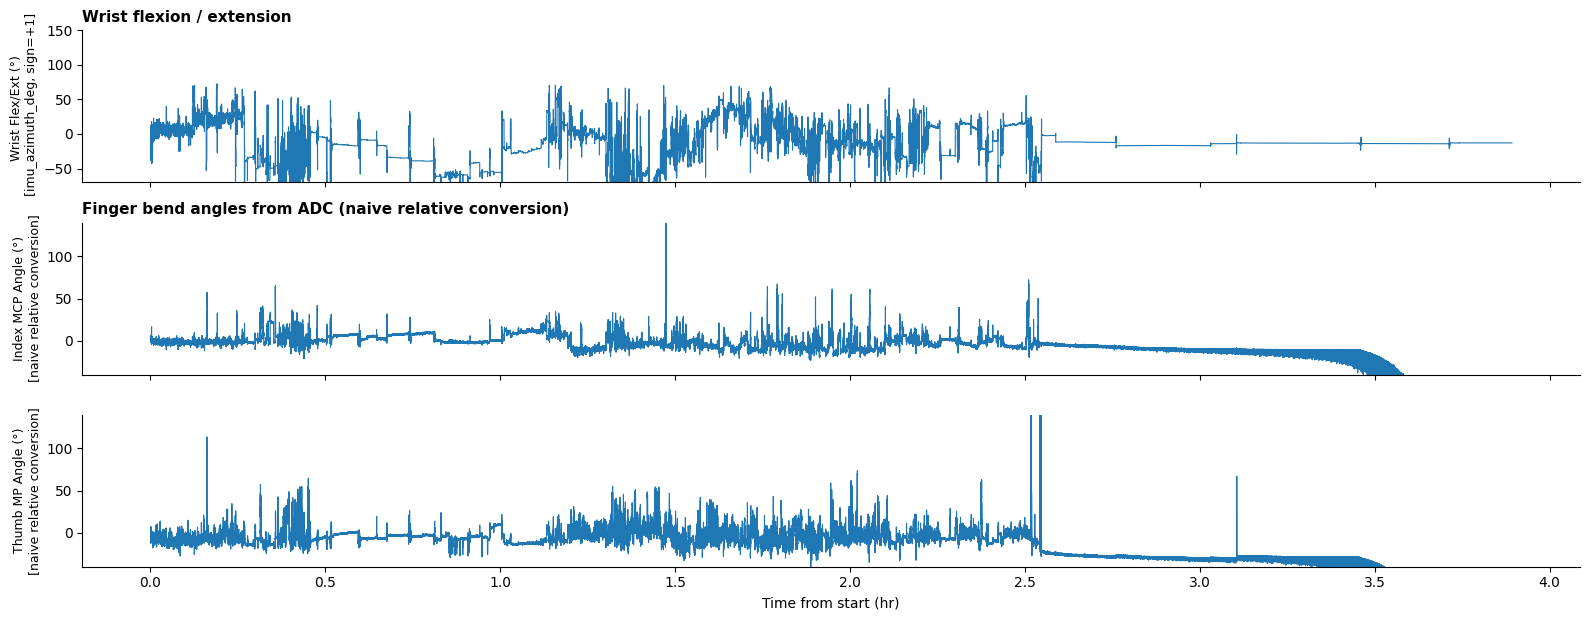

In [318]:
# labels + angle-only plot

display_name_map["index_mcp_deg"] = "Index MCP Angle (°)\n[naive relative conversion]"
display_name_map["thumb_mp_deg"] = "Thumb MP Angle (°)\n[naive relative conversion]"
group_title_map["Finger angles"] = "Finger bend angles from ADC (naive relative conversion)"

plot_groups_final = {
    "Wrist FE": ["wrist_flex_ext_deg"],
    "Finger angles": ["index_mcp_deg", "thumb_mp_deg"],
}

plot_groups_final = {
    k: [c for c in v if c in df_final.columns]
    for k, v in plot_groups_final.items()
    if any(c in df_final.columns for c in v)
}

adc_ylim_map_final = {
    "wrist_flex_ext_deg": (-70, 150),
    "index_mcp_deg": (-40, 140),
    "thumb_mp_deg": (-40, 140),
}


plot_all_signals_one_figure(
    df_final,
    plot_groups_final,
    manual_segments=manual_segments,
    bluetooth_segments=bluetooth_segments,
    adc_disconnect_segments=adc_disconnect_segments,
    imu2_disconnect_segments=imu2_disconnect_segments,
    label_colors=label_colors,
    display_name_map=display_name_map,
    group_title_map=group_title_map,
    adc_ylim_map=adc_ylim_map_final,
    xcol="elapsed_hr",
)